# Karaoke Scoring Pipeline Implementation

This notebook implements the karaoke scoring pipeline.
It features:
- **RMS Gating**: To remove pitch jitter in silent/unvoiced parts.
- **F0-based DTW Alignment**: To align vocal recordings with MIDI melody using pitch contours.
- **Scoring**: Weighted scoring based on pitch accuracy.
- **Visualization**: Interactive plot using `ipympl`.

## 1. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import scipy.interpolate
try:
    import pretty_midi
except ImportError:
    print("Installing pretty_midi...")
    !pip install pretty_midi
    import pretty_midi

try:
    import mido
except ImportError:
    print("Installing mido...")
    !pip install mido
    import mido

try:
    import ipympl
except ImportError:
    print("Installing ipympl...")
    !pip install ipympl
    import ipympl

# %matplotlib widget

## 2. Load Data & MIDI Extraction (Channel 0)

In [2]:
# Constants
VOCAL_PATH = 'vocal.mp3'
MIDI_PATH = 'song.mid'
A4_FREQ = 440.0
SEMITONE_REF_PITCH = 69

print(f"Loading {VOCAL_PATH}...")
y, sr = librosa.load(VOCAL_PATH, sr=None)
print(f"Audio: {len(y)/sr:.2f}s, SR={sr}")

mid = mido.MidiFile(MIDI_PATH)
pm = pretty_midi.PrettyMIDI(MIDI_PATH)
resolution = pm.resolution

# Manually extract Channel 0 notes
chan0_notes = []
for track in mid.tracks:
    abs_time = 0
    active_notes = {}
    for msg in track:
        abs_time += msg.time
        if msg.type == 'note_on' and msg.velocity > 0:
            if msg.channel == 0:
                active_notes[msg.note] = abs_time
        elif msg.type == 'note_off' or (msg.type == 'note_on' and msg.velocity == 0):
            if msg.channel == 0:
                if msg.note in active_notes:
                    start_tick = active_notes.pop(msg.note)
                    chan0_notes.append({
                        'start': pm.tick_to_time(start_tick),
                        'end': pm.tick_to_time(abs_time),
                        'pitch': msg.note
                    })
chan0_notes.sort(key=lambda x: x['start'])
print(f"Extracted {len(chan0_notes)} melody notes from Channel 0.")

Loading vocal.mp3...
Audio: 326.05s, SR=48000
Extracted 474 melody notes from Channel 0.


## 3. Pitch Detection with RMS Gating

Running Pitch Detection...


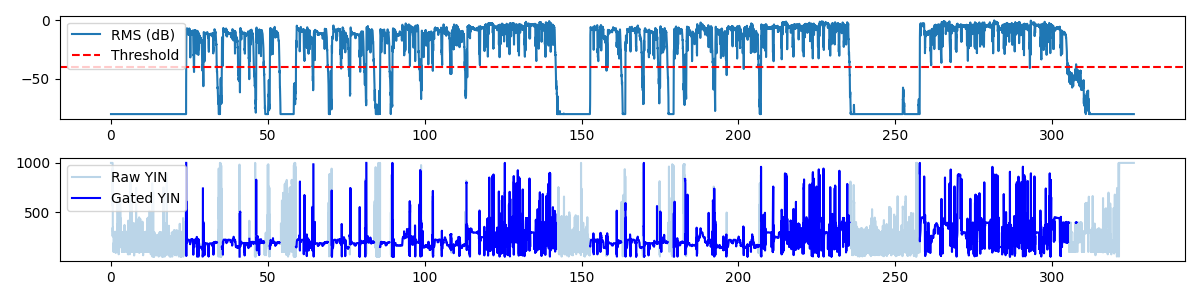

In [3]:
N_FFT = 2048
HOP_LENGTH = N_FFT // 8 # 256

# 1. Calculate RMS Energy
rms = librosa.feature.rms(y=y, frame_length=N_FFT, hop_length=HOP_LENGTH)[0]

# 2. Calculate F0 (YIN)
print("Running Pitch Detection...")
# Standard YIN
f0 = librosa.yin(y, fmin=50, fmax=1000, sr=sr, frame_length=N_FFT, hop_length=HOP_LENGTH)

# or try P-YIN for more accurate (but not suitable for realtime, very slow)
#f0, voiced_flag, voiced_probs = librosa.pyin(y,sr=sr,hop_length=HOP_LENGTH, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'))

times_raw = librosa.times_like(f0, sr=sr, hop_length=HOP_LENGTH)

# 3. RMS Gating
# Normalize RMS
rms_db = librosa.amplitude_to_db(rms, ref=np.max)
RMS_THRESHOLD_DB = -40.0 # Adjust as needed (silence threshold)

f0_gated = f0.copy()
# Align lengths if mismatch (librosa padding can cause small diff)
min_len = min(len(f0_gated), len(rms_db))
f0_gated = f0_gated[:min_len]
rms_db = rms_db[:min_len]
times_raw = times_raw[:min_len]

mask_silence = rms_db < RMS_THRESHOLD_DB
f0_gated[mask_silence] = np.nan

plt.figure(figsize=(12, 3))
plt.subplot(2, 1, 1)
plt.plot(times_raw, rms_db, label='RMS (dB)')
plt.axhline(RMS_THRESHOLD_DB, color='r', linestyle='--', label='Threshold')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(times_raw, f0, alpha=0.3, label='Raw YIN')
plt.plot(times_raw, f0_gated, color='blue', label='Gated YIN')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Audio-MIDI Alignment (Optimized F0 DTW)

Shifted audio by 1 octaves.
Running DTW on coarse contours (Factor 16, Size: 3821)...


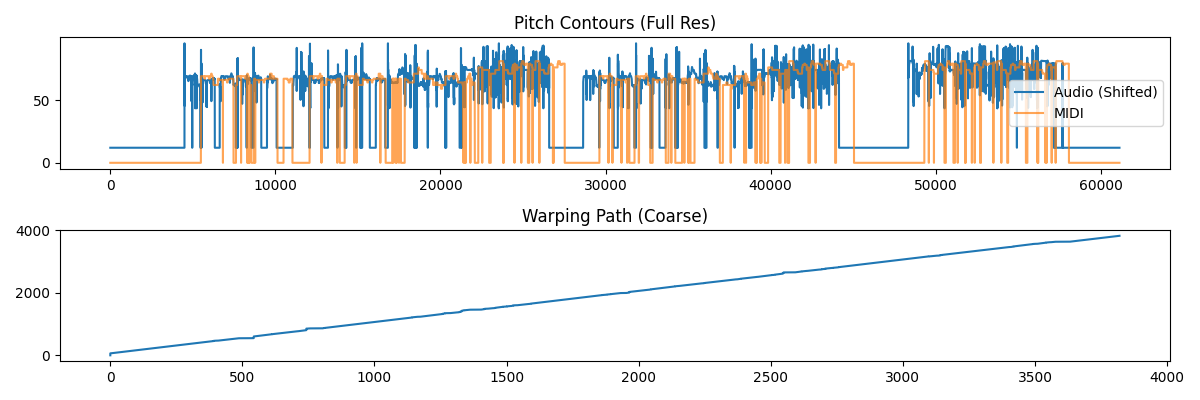

In [4]:
# Prepare Audio Pitch Contour
f0_midi = 12 * np.log2(f0_gated / A4_FREQ) + 69
f0_midi[np.isnan(f0_midi)] = 0

def interpolate_nans(a):
    nans, x = np.isnan(a), lambda z: z.nonzero()[0]
    if np.all(nans): return np.zeros_like(a)
    a[nans] = np.interp(x(nans), x(~nans), a[~nans])
    return a

f0_clean = f0_midi.copy()
f0_clean = interpolate_nans(f0_clean)

# Prepare MIDI Pitch Contour
midi_curve = np.zeros_like(f0_clean)
dt = times_raw[1] - times_raw[0]

for note in chan0_notes:
    start_idx = int(note['start'] / dt)
    end_idx = int(note['end'] / dt)
    # Bound checks
    start_idx = max(0, min(start_idx, len(midi_curve)-1))
    end_idx = max(0, min(end_idx, len(midi_curve)-1))
    midi_curve[start_idx:end_idx] = note['pitch']

# Octave Normalization
valid_midi = midi_curve[midi_curve > 0]
if len(valid_midi) > 0:
    mean_midi = np.median(valid_midi)
    mean_audio = np.median(f0_clean)
    diff = mean_midi - mean_audio
    shift_octaves = round(diff / 12)
    f0_shifted = f0_clean + (shift_octaves * 12)
    print(f"Shifted audio by {shift_octaves} octaves.")
else:
    f0_shifted = f0_clean

# --- DTW OPTIMIZATION ---
# Downsample contours to ~10-20Hz to prevent kernel crashes due to memory/time complexity.
# Original F0 is approx 44100/256 = 172 Hz.
# Factor of 16 gives ~10.75 Hz.
DOWNSAMPLE_FACTOR = 16

f0_coarse = f0_shifted[::DOWNSAMPLE_FACTOR]
midi_coarse = midi_curve[::DOWNSAMPLE_FACTOR]

print(f"Running DTW on coarse contours (Factor {DOWNSAMPLE_FACTOR}, Size: {len(f0_coarse)})...")
D, wp = librosa.sequence.dtw(X=f0_coarse, Y=midi_coarse, metric='euclidean')
wp = wp[::-1]

# Time Mapping (Scales Indices by Downsample Factor)
time_audio_idx = wp[:, 0] * DOWNSAMPLE_FACTOR
time_midi_idx = wp[:, 1] * DOWNSAMPLE_FACTOR

# Clamp indices to original bounds just in case
time_audio_idx = np.clip(time_audio_idx, 0, len(times_raw) - 1)
time_midi_idx = np.clip(time_midi_idx, 0, len(times_raw) - 1)

time_audio_est = times_raw[time_audio_idx]
time_midi_est = times_raw[time_midi_idx]

# Interpolate
u_audio, u_indices = np.unique(time_audio_est, return_index=True)
u_midi = time_midi_est[u_indices]

map_time = scipy.interpolate.interp1d(u_audio, u_midi, kind='linear', fill_value="extrapolate")

plt.figure(figsize=(12, 4))
plt.subplot(2, 1, 1)
plt.plot(f0_shifted, label='Audio (Shifted)')
plt.plot(midi_curve, label='MIDI', alpha=0.7)
plt.title('Pitch Contours (Full Res)')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(wp[:, 0], wp[:, 1])
plt.title('Warping Path (Coarse)')
plt.tight_layout()
plt.show()

## 5. Scoring with Gated F0 & Aligned Time

Final Score: 85.1 / 100
Visualization: shifting sung notes by 12 semitones to match target octave.


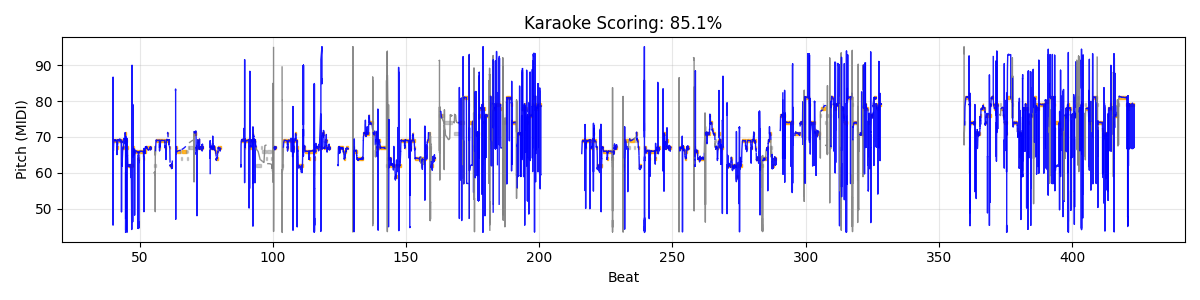

In [5]:
player_segments = []
current_segment = None
frames_results = []

# Update target notes list for scoring
target_notes = []
def time_to_beat(t): return pm.time_to_tick(t) / resolution

for note in chan0_notes:
    target_notes.append({
        'start_beat': time_to_beat(note['start']),
        'end_beat': time_to_beat(note['end']),
        'pitch': note['pitch']
    })

# Process frames
for i, f_hz in enumerate(f0_gated):
    t_raw = times_raw[i]
    # Align time
    t_aligned = map_time(t_raw)
    b_aligned = time_to_beat(t_aligned)
    
    if np.isnan(f_hz):
        frames_results.append(None)
        continue
        
    # Find Note
    matched = None
    for note in target_notes:
        if note['start_beat'] <= b_aligned <= note['end_beat']:
            matched = note
            break
    
    if not matched:
        frames_results.append(None)
        continue
        
    # Distance
    p_hat = 12 * np.log2(f_hz / A4_FREQ) + 69
    delta = (p_hat - matched['pitch'])
    # Nearest octave
    delta = (delta + 6) % 12 - 6
    
    frames_results.append({
        'beat': b_aligned,
        'pitch': p_hat,
        'note': matched,
        'distance': 0 if abs(delta) < 1.0 else delta
    })

# Segment formation (Simplified)
for frame in frames_results:
    if frame is None:
        continue
    
    if current_segment and current_segment['note'] == frame['note'] and abs(frame['beat'] - current_segment['end_beat']) < 0.5:
        current_segment['end_beat'] = frame['beat']
        current_segment['frames'].append(frame)
    else:
        if current_segment: player_segments.append(current_segment)
        current_segment = {
            'note': frame['note'],
            'start_beat': frame['beat'],
            'end_beat': frame['beat'],
            'frames': [frame]
        }
if current_segment: player_segments.append(current_segment)

# Scoring
score = 0
total_duration = sum(n['end_beat'] - n['start_beat'] for n in target_notes)
sung_duration = 0

for seg in player_segments:
    # Check average distance
    # Actually, pipeline says per frame, or if segment distance is 0.
    # Let's say if majority of frames are distance 0.
    dists = [f['distance'] for f in seg['frames']]
    if dists.count(0) > len(dists) / 2:
        sung_duration += (seg['end_beat'] - seg['start_beat'])

print(f"Final Score: {sung_duration/total_duration*100:.1f} / 100")

# --- Visualization Logic ---
# Determine if each target note was 'hit' (Correctly sung)
for note in target_notes:
    note_duration = note['end_beat'] - note['start_beat']
    correct_duration = 0
    for seg in player_segments:
        dists = [f['distance'] for f in seg['frames']]
        is_seg_correct = dists.count(0) > len(dists) / 2
        
        if is_seg_correct:
            # Calculate overlap
            start = max(note['start_beat'], seg['start_beat'])
            end = min(note['end_beat'], seg['end_beat'])
            if end > start:
                correct_duration += (end - start)
    
    # Threshold: Hit if > 50% overlap
    note['is_hit'] = correct_duration >= (0.5 * note_duration)

# Visualization Shift
target_pitches = [n['pitch'] for n in target_notes]
sung_pitches = []
for seg in player_segments:
    sung_pitches.extend([f['pitch'] for f in seg['frames']])

vis_shift = 0
if len(target_pitches) > 0 and len(sung_pitches) > 0:
    median_target = np.median(target_pitches)
    median_sung = np.median(sung_pitches)
    diff = median_target - median_sung
    vis_shift = round(diff / 12) * 12
    print(f"Visualization: shifting sung notes by {vis_shift} semitones to match target octave.")

# Plotting
plt.close('all')
fig, ax = plt.subplots(figsize=(12, 3))

import matplotlib.patches as patches

# 1. Plot Target Melody Blocks
# Hit -> Orange, Miss -> Grey
for note in target_notes:
    color = 'orange' if note.get('is_hit', False) else 'grey'
    alpha = 0.8 if note.get('is_hit', False) else 0.4
    
    rect = patches.Rectangle((note['start_beat'], note['pitch'] - 0.4),
                             note['end_beat'] - note['start_beat'],
                             0.8,
                             linewidth=1, edgecolor=color, facecolor=color, alpha=alpha, 
                             label='Target' if note == target_notes[0] else "")
    ax.add_patch(rect)

# 2. Plot Sung Pitch Contour
# Correct -> Blue, Incorrect -> Grey, Linewidth 1px
for seg in player_segments:
    dists = [f['distance'] for f in seg['frames']]
    is_correct = dists.count(0) > len(dists) / 2
    
    color = 'blue' if is_correct else 'grey'
    alpha = 0.9
    linewidth = 1
    
    seg_beats = [f['beat'] for f in seg['frames']]
    seg_pitches = [f['pitch'] + vis_shift for f in seg['frames']]
    
    ax.plot(seg_beats, seg_pitches, color=color, linewidth=linewidth, alpha=alpha, 
            label='Sung' if seg == player_segments[0] else "")

ax.set_xlabel('Beat')
ax.set_ylabel('Pitch (MIDI)')
ax.set_title(f'Karaoke Scoring: {sung_duration/total_duration*100:.1f}%')
ax.autoscale()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()